In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

df = pd.read_csv('data_praktikum_analisis_data.csv')
print("5 data teratas:")
print(df.head())
print("\nInformasi dataset:")
print(df.info())

5 data teratas:
   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date       

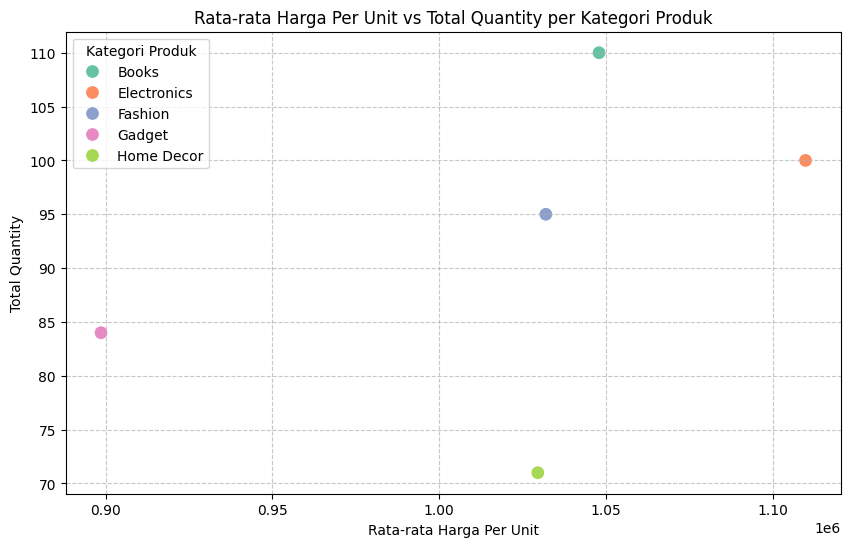

In [10]:
if 'Product_Category' in df.columns and 'Quantity' in df.columns:
    product_data = df.groupby('Product_Category').agg({
        'Price_Per_Unit': 'mean',
        'Quantity': 'sum'
    }).reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=product_data,
        x='Price_Per_Unit',
        y='Quantity',
        hue='Product_Category',
        palette='Set2',
        s=100
    )
    
    plt.title('Rata-rata Harga Per Unit vs Total Quantity per Kategori Produk')
    plt.xlabel('Rata-rata Harga Per Unit')
    plt.ylabel('Total Quantity')
    plt.legend(title='Kategori Produk')
    plt.grid(True, linestyle='--', alpha=0.7)
else:
    print("Kolom 'Product_Category' atau 'Quantity' tidak ditemukan dalam dataset.")    

In [12]:
if 'CustomerID' in df.columns and 'Order_Date' in df.columns:
    current_date = pd.to_datetime(df['Order_Date'].max()) + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (current_date - pd.to_datetime(x).max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
}).reset_index()
rfm.rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Total_Sales': 'Monetary'
}, inplace=True)
print("\nRFM Table:")
print(rfm.head())


RFM Table:
   CustomerID  Recency  Frequency    Monetary
0        5001      213          4   8562000.0
1        5002       77          4   6931000.0
2        5003      118          3   9433000.0
3        5004      196          3  15368000.0
4        5005       23          2   9105000.0


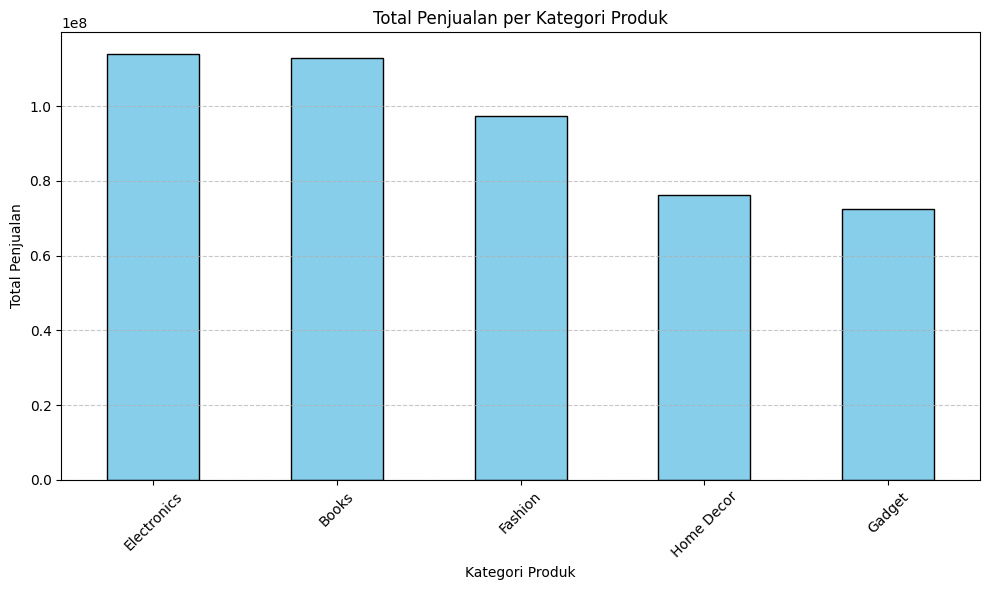

In [ ]:
df['Total_Sales'] = df['Quantity'] * df['Price_Per_Unit']

if 'Product_Category' in df.columns:
    category_profit = df.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    category_profit.plot(kind='bar', color='skyblue', edgecolor='black')
    
    plt.title('Total Penjualan per Kategori Produk')
    plt.xlabel('Kategori Produk')
    plt.ylabel('Total Penjualan')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'Product_Category' tidak ditemukan dalam dataset.")    

In [16]:
if 'Discount_Percentage' in df.columns:
    diskon_tinggi = df[df['Discount_Percentage'] > 20]
    diskon_rendah = df[df['Discount_Percentage'] <= 20]
    print(f"Rata-rata Volume (Diskon > 20%): {diskon_tinggi['Quantity'].mean()}")
    print(f"Rata-rata Volume (Diskon <= 20%): {diskon_rendah['Quantity'].mean()}")
else:
    print("Kolom 'Discount_Percentage' tidak ditemukan.")

Kolom 'Discount_Percentage' tidak ditemukan.


In [17]:
import numpy as np

df['Discount_Sim'] = np.where(df['Quantity'] > 3, 25, 10) 
df['Total_Sales'] = df['Quantity'] * df['Price_Per_Unit']
df['Profit_Sim'] = df['Total_Sales'] * 0.15 

diskon_tinggi = df[df['Discount_Sim'] > 20]
diskon_rendah = df[df['Discount_Sim'] <= 20]

avg_vol_tinggi = diskon_tinggi['Quantity'].mean()
avg_profit_tinggi = diskon_tinggi['Profit_Sim'].mean()
new_customer_tinggi = diskon_tinggi['CustomerID'].nunique()

print(f"--- Hasil Uji Hipotesis ---")
print(f"Kelompok Diskon > 20%: Avg Vol = {avg_vol_tinggi:.2f}, Avg Profit = {avg_profit_tinggi:.2f}")
print(f"Kelompok Diskon <= 20%: Avg Vol = {diskon_rendah['Quantity'].mean():.2f}")

--- Hasil Uji Hipotesis ---
Kelompok Diskon > 20%: Avg Vol = 4.55, Avg Profit = 720602.34
Kelompok Diskon <= 20%: Avg Vol = 1.97


=== Uji Pengaruh Ad_Budget ===
Median Ad_Budget       : Rp 2,722,500
Jumlah data Iklan Tinggi: 75 transaksi
Jumlah data Iklan Rendah: 75 transaksi
Rata-rata Sales (Iklan Tinggi) : Rp 3,079,293.33
Rata-rata Sales (Iklan Rendah) : Rp 3,231,280.00
Selisih                        : Rp -151,986.67


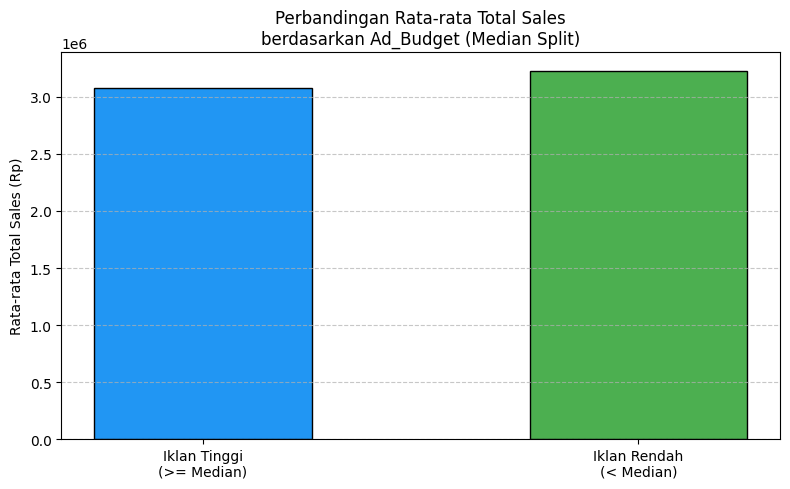

In [18]:
# Cell 6: Uji Pengaruh Ad_Budget terhadap Total_Sales (berdasarkan median)
median_budget = df['Ad_Budget'].median()

iklan_tinggi = df[df['Ad_Budget'] >= median_budget]
iklan_rendah = df[df['Ad_Budget'] < median_budget]

avg_sales_tinggi = iklan_tinggi['Total_Sales'].mean()
avg_sales_rendah = iklan_rendah['Total_Sales'].mean()

print("=== Uji Pengaruh Ad_Budget ===")
print(f"Median Ad_Budget       : Rp {median_budget:,.0f}")
print(f"Jumlah data Iklan Tinggi: {len(iklan_tinggi)} transaksi")
print(f"Jumlah data Iklan Rendah: {len(iklan_rendah)} transaksi")
print(f"Rata-rata Sales (Iklan Tinggi) : Rp {avg_sales_tinggi:,.2f}")
print(f"Rata-rata Sales (Iklan Rendah) : Rp {avg_sales_rendah:,.2f}")
print(f"Selisih                        : Rp {avg_sales_tinggi - avg_sales_rendah:,.2f}")

plt.figure(figsize=(8, 5))
plt.bar(
    ['Iklan Tinggi\n(>= Median)', 'Iklan Rendah\n(< Median)'],
    [avg_sales_tinggi, avg_sales_rendah],
    color=['#2196F3', '#4CAF50'],
    edgecolor='black',
    width=0.5
)
plt.title('Perbandingan Rata-rata Total Sales\nberdasarkan Ad_Budget (Median Split)')
plt.ylabel('Rata-rata Total Sales (Rp)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


=== RFM Analysis dengan Segmentasi ===
 CustomerID  Recency  Frequency   Monetary R_Score F_Score M_Score RFM_Group      Segment
       5001      213          4  8562000.0       1       4       3       143      At Risk
       5002       77          4  6931000.0       3       4       3       343        Loyal
       5003      118          3  9433000.0       3       2       3       323    Potential
       5004      196          3 15368000.0       2       3       4       234      At Risk
       5005       23          2  9105000.0       5       2       3       523 New Customer
       5006      174          1  1550000.0       2       1       1       211    Potential
       5007       35          4  7520000.0       4       4       3       443        Loyal
       5008       15          6 22350000.0       5       5       5       555    Champions
       5009       12          5  9334000.0       5       5       3       553        Loyal
       5010      136          1  5630000.0       2       1  

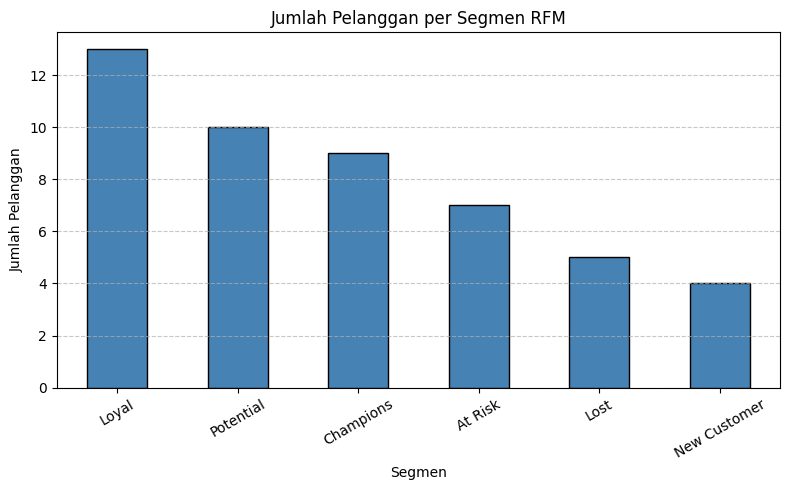

In [19]:
# Cell 7: RFM Scoring (lanjutan dari cell 3)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

def segmentasi_rfm(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 1 and m <= 2:
        return 'Lost'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segmentasi_rfm, axis=1)

print("\n=== RFM Analysis dengan Segmentasi ===")
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
           'R_Score', 'F_Score', 'M_Score', 'RFM_Group', 'Segment']].head(10).to_string(index=False))

print("\nJumlah pelanggan per segmen:")
print(rfm['Segment'].value_counts())

plt.figure(figsize=(8, 5))
rfm['Segment'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Jumlah Pelanggan per Segmen RFM')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== Regresi Linear: Ad_Budget → Total_Sales ===
Koefisien Iklan  : 0.0895
Intercept        : 2,813,343.69
R² Score (test)  : -0.0728
RMSE             : 2,186,375.78


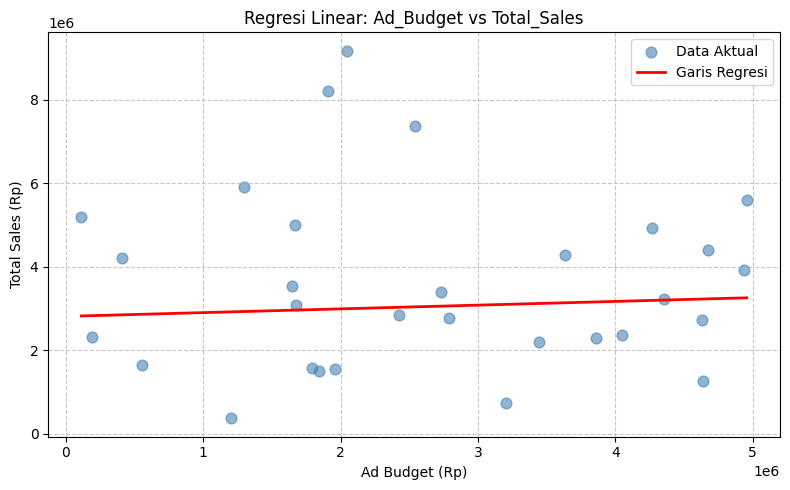

In [29]:
# Cell 8: Regresi Linear Sederhana (Ad_Budget → Total_Sales)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

df_reg = df[['Ad_Budget', 'Total_Sales']].dropna()

X = df_reg[['Ad_Budget']]
y = df_reg['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Regresi Linear: Ad_Budget → Total_Sales ===")
print(f"Koefisien Iklan  : {model.coef_[0]:.4f}")
print(f"Intercept        : {model.intercept_:,.2f}")
print(f"R² Score (test)  : {r2:.4f}")
print(f"RMSE             : {rmse:,.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, label='Data Aktual', s=60)

# Plot regression line (urutkan X untuk garis yang平滑)
X_test_sorted = X_test.sort_values('Ad_Budget')
y_pred_sorted = model.predict(X_test_sorted)
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Garis Regresi')

plt.title('Regresi Linear: Ad_Budget vs Total_Sales')
plt.xlabel('Ad Budget (Rp)')
plt.ylabel('Total Sales (Rp)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9: Ringkasan Hasil Analisis
print("=" * 55)
print("       RINGKASAN HASIL ANALISIS DATA PENJUALAN")
print("=" * 55)

print("\n[1] PENGARUH AD_BUDGET TERHADAP TOTAL_SALES")
print(f"  Median Ad_Budget          : Rp {median_budget:,.0f}")
print(f"  Avg Sales - Iklan Tinggi  : Rp {avg_sales_tinggi:,.2f}")
print(f"  Avg Sales - Iklan Rendah  : Rp {avg_sales_rendah:,.2f}")
selisih_pct = ((avg_sales_tinggi - avg_sales_rendah) / avg_sales_rendah) * 100
print(f"  Selisih                   : {selisih_pct:+.1f}%")
kesimpulan = "signifikan" if abs(selisih_pct) > 10 else "tidak signifikan secara substansial"
print(f"  Kesimpulan                : Pengaruh iklan {kesimpulan}")

print("\n[2] RFM SEGMENTASI PELANGGAN")
for seg, count in rfm['Segment'].value_counts().items():
    pct = count / len(rfm) * 100
    print(f"  {seg:<15}: {count} pelanggan ({pct:.1f}%)")

print("\n[3] MODEL REGRESI LINEAR")
print(f"  Koefisien Ad_Budget : {model.coef_[0]:.4f}")
print(f"  Intercept           : {model.intercept_:,.0f}")
print(f"  R² Score            : {r2:.4f} ({r2*100:.1f}% variasi dijelaskan oleh model)")
print(f"  RMSE                : Rp {rmse:,.0f}")
kualitas = "kuat" if r2 > 0.5 else "lemah/sedang"
print(f"  Kualitas Model      : {kualitas}")

print("\n[4] SIMULASI DISKON")
avg_vol_tinggi_sim = df[df['Discount_Sim'] > 20]['Quantity'].mean()
avg_vol_rendah_sim = df[df['Discount_Sim'] <= 20]['Quantity'].mean()
avg_profit_tinggi_sim = df[df['Discount_Sim'] > 20]['Profit_Sim'].mean()
print(f"  Avg Quantity - Diskon Tinggi : {avg_vol_tinggi_sim:.2f}")
print(f"  Avg Quantity - Diskon Rendah : {avg_vol_rendah_sim:.2f}")
print(f"  Avg Profit   - Diskon Tinggi : Rp {avg_profit_tinggi_sim:,.2f}")
print("=" * 55)

       RINGKASAN HASIL ANALISIS DATA PENJUALAN

[1] PENGARUH AD_BUDGET TERHADAP TOTAL_SALES
  Median Ad_Budget          : Rp 2,722,500
  Avg Sales - Iklan Tinggi  : Rp 3,079,293.33
  Avg Sales - Iklan Rendah  : Rp 3,231,280.00
  Selisih                   : -4.7%
  Kesimpulan                : Pengaruh iklan tidak signifikan secara substansial

[2] RFM SEGMENTASI PELANGGAN
  Loyal          : 13 pelanggan (27.1%)
  Potential      : 10 pelanggan (20.8%)
  Champions      : 9 pelanggan (18.8%)
  At Risk        : 7 pelanggan (14.6%)
  Lost           : 5 pelanggan (10.4%)
  New Customer   : 4 pelanggan (8.3%)

[3] MODEL REGRESI LINEAR
  Koefisien Ad_Budget : 0.0895
  Intercept           : 2,813,344
  R² Score            : -0.0728 (-7.3% variasi dijelaskan oleh model)
  RMSE                : Rp 2,186,376
  Kualitas Model      : lemah/sedang

[4] SIMULASI DISKON
  Avg Quantity - Diskon Tinggi : 4.55
  Avg Quantity - Diskon Rendah : 1.97
  Avg Profit   - Diskon Tinggi : Rp 720,602.34
